In [19]:
import os
from pathlib import Path
import zarr
import numpy as np
import pandas as pd
from geff import read
import matplotlib.pyplot as plt

In [20]:
# DATA LOCATION
INPUT_ROOT= Path('data/biohub-cell-tracking-during-development/')

# DISPLAY FOLDERS AND FILES INSIDE THE INPUT ROOT
if INPUT_ROOT.exists():
    for path in sorted(INPUT_ROOT.iterdir()):
        print(path.name)
else:
    print(f"Folder {INPUT_ROOT.name} not found!")
    # check parent folder
    parent_folder = INPUT_ROOT.parent
    if parent_folder.exists():
        print(f"\nAvailable folder {parent_folder}:")
        for path in sorted(parent_folder.iterdir()):
            print(path.name)
    else:
        print(f"Parent folder {parent_folder} found!")

sample_submission.csv
test
train


In [21]:
train_root = INPUT_ROOT/"train"
test_root = INPUT_ROOT/"test"

train_entries = sorted(train_root.iterdir())
test_entries = sorted(test_root.iterdir())

print(F"Number of train entries: {len(train_entries)}")
print(F"Number of test entries: {len(test_entries)}")

print("\nFirst five train entries:")
for path in train_entries[:5]:
    print(path.name)

print("\nFirst five test entries:")
for path in test_entries[:5]:
    print(path.name)

Number of train entries: 398
Number of test entries: 4

First five train entries:
44b6_0113de3b.geff
44b6_0113de3b.zarr
44b6_0b24845f.geff
44b6_0b24845f.zarr
44b6_0c582fdc.geff

First five test entries:
44b6_0113de3b.zarr
44b6_0b24845f.zarr
6bba_05b6850b.zarr
6bba_05db0fb1.zarr


## File Inspection
### Inspect .zarr file

In [22]:
# zarr sample
zarr_file_path = train_root/"44b6_0113de3b.zarr"

# open zarr hierarchy
z_root = zarr.open(zarr_file_path, mode='r')
# inspect root hierarchy structure
zarr_root_keys = list(z_root.keys())

# main image array
main_array = z_root['0']
print(f"Shape: {main_array.shape}")
print(f"Data Type: {main_array.dtype}")


Shape: (100, 64, 256, 256)
Data Type: uint16


**Notes**: Shape represents (Time, Depth, Height, width)
- T = 100, means that there are 100 time points each zarr file. Furthermore, there are 100 moments of image captured. For example, if the microscope is set to record every one minute, means that this data records cell movement for 100 minutes.
- Z = 64, means each 3D frame has 64 slices (optical depth). Unlike flat 2D image captured by regular camera or phone, this specialized microscope captured the object (cell) optically from bottom to topmost part. So every time, there are 64 stack of images. This make it possible for us to observe whether the cells move up, down, or overlap to each other.
- Y & X = 256, means the size is 256 x 256 voxels. The height and the weight of each slices in pixels. 
- Unsigned integer 16-bit (Uint16). Standard images, usually use uint8, which ranges from 0 to 255. `uint16` ranges from 0 to 65.535, meaning that the light intensity is wider. This is super important to capture the fluorence signal from the cells so that it can capture all cells, brightest and very faint light intensity.



### Inspect .geff file (Ground-Truth Targets)

In [23]:
geff_file_path = train_root/"44b6_0113de3b.geff"

graph, _ = read(geff_file_path, backend='networkx')

node_data = list(graph.nodes(data=True))

print(f"Total nodes detected: {graph.number_of_nodes()}")
print(f"Temporal links (number of edges): {graph.number_of_edges()}")

# first 10 nodes and attributes
print("\nFirst 10 nodes:")
for node in node_data:
    print(node)

Total nodes detected: 52
Temporal links (number of edges): 50

First 10 nodes:
(11000000075, {'t': 0, 'z': 63, 'x': 249, 'y': 222})
(12000000075, {'t': 1, 'z': 63, 'x': 251, 'y': 227})
(13000000075, {'t': 2, 'z': 63, 'x': 253, 'y': 230})
(38000000003, {'t': 27, 'z': 1, 'x': 73, 'y': 74})
(39000000003, {'t': 28, 'z': 3, 'x': 75, 'y': 78})
(40000000003, {'t': 29, 'z': 5, 'x': 77, 'y': 80})
(41000000003, {'t': 30, 'z': 7, 'x': 78, 'y': 86})
(42000000003, {'t': 31, 'z': 9, 'x': 77, 'y': 91})
(43000000003, {'t': 32, 'z': 11, 'x': 81, 'y': 98})
(44000000003, {'t': 33, 'z': 11, 'x': 78, 'y': 104})
(45000000003, {'t': 34, 'z': 13, 'x': 79, 'y': 109})
(46000000003, {'t': 35, 'z': 14, 'x': 80, 'y': 112})
(47000000003, {'t': 36, 'z': 15, 'x': 83, 'y': 110})
(48000000003, {'t': 37, 'z': 16, 'x': 84, 'y': 114})
(49000000003, {'t': 38, 'z': 16, 'x': 83, 'y': 114})
(50000000003, {'t': 39, 'z': 18, 'x': 89, 'y': 114})
(51000000003, {'t': 40, 'z': 19, 'x': 92, 'y': 116})
(52000000003, {'t': 41, 'z': 19

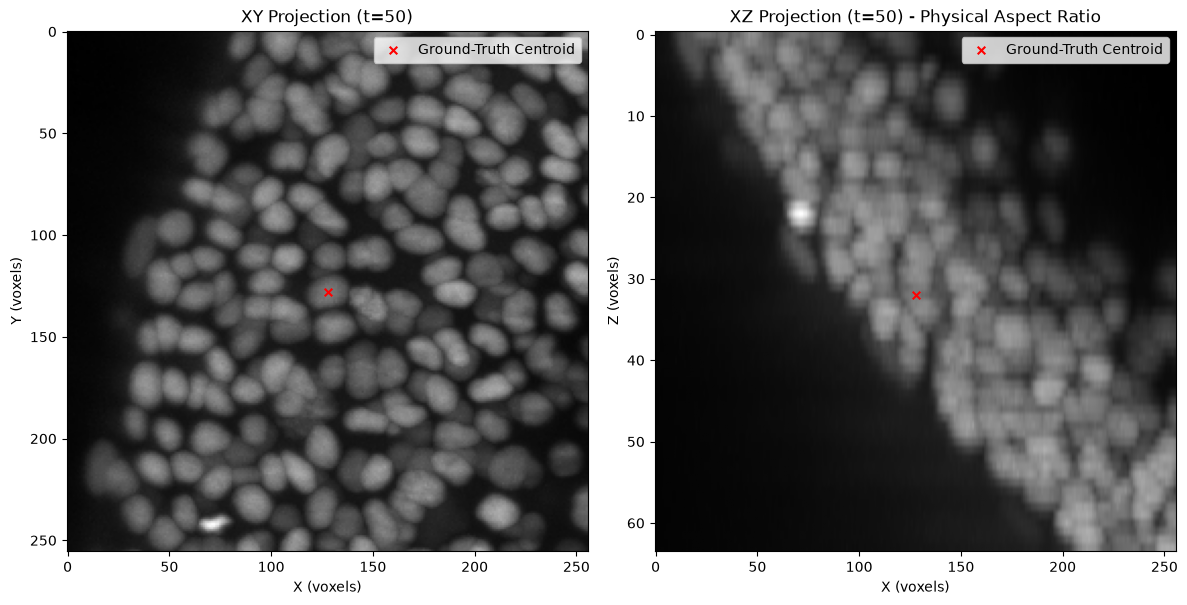

In [12]:
def visualize_frame_with_nodes(zarr_array, graph, t_frame=50):
    # Extract 3D raw volume for timepoint t_frame
    # shape: (Z, Y, X)
    volume_3d = zarr_array[t_frame]
    
    # Extract ground-truth nodes for this exact timepoint
    nodes_at_t = [
        data for node_id, data in graph.nodes(data=True) 
        if data.get('t') == t_frame
    ]
    
    # Separate centroid coordinates
    z_coords = [n['z'] for n in nodes_at_t]
    y_coords = [n['y'] for n in nodes_at_t]
    x_coords = [n['x'] for n in nodes_at_t]
    
    # Compute 2D Maximum Intensity Projections (MIP)
    mip_xy = np.max(volume_3d, axis=0) # Compress Z-axis
    mip_xz = np.max(volume_3d, axis=1) # Compress Y-axis
    
    # Plot projections with centroid overlays
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Plot XY projection (Y vs X)
    axes[0].imshow(mip_xy, cmap='gray')
    axes[0].scatter(x_coords, y_coords, color='red', s=30, marker='x', label='Ground-Truth Centroid')
    axes[0].set_title(f"XY Projection (t={t_frame})")
    axes[0].set_xlabel("X (voxels)")
    axes[0].set_ylabel("Y (voxels)")
    axes[0].legend()
    
    # Plot XZ projection (Z vs X)
    axes[1].imshow(mip_xz, cmap='gray', aspect=1.625/0.40625) # Apply physical aspect ratio
    axes[1].scatter(x_coords, z_coords, color='red', s=30, marker='x', label='Ground-Truth Centroid')
    axes[1].set_title(f"XZ Projection (t={t_frame}) - Physical Aspect Ratio")
    axes[1].set_xlabel("X (voxels)")
    axes[1].set_ylabel("Z (voxels)")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Run visualization on frame 0
visualize_frame_with_nodes(main_array, graph, t_frame=50)

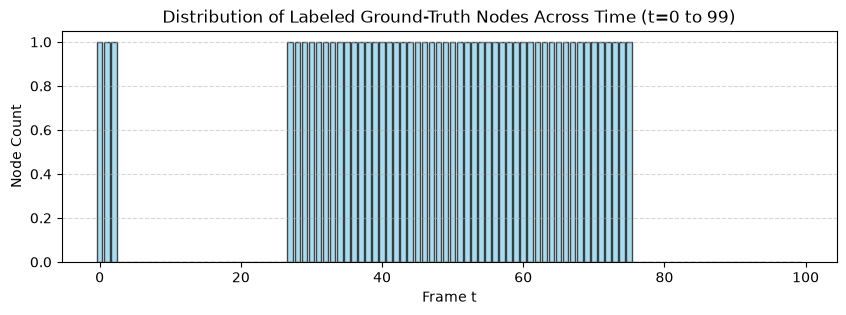

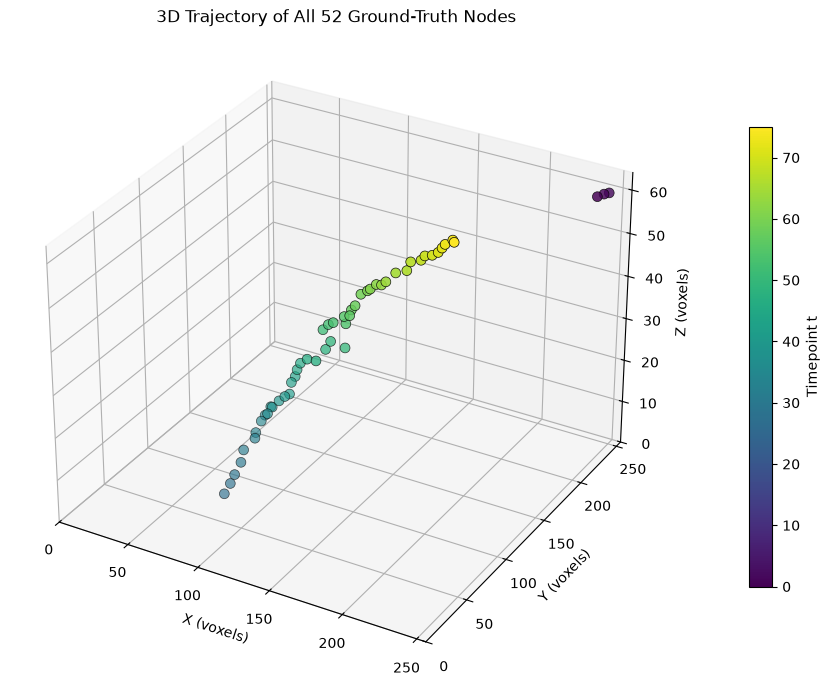

In [13]:
import matplotlib.pyplot as plt
from collections import Counter

# Extract node coordinate attributes
node_data = [data for _, data in graph.nodes(data=True)]

t_coords = [n['t'] for n in node_data]
z_coords = [n['z'] for n in node_data]
y_coords = [n['y'] for n in node_data]
x_coords = [n['x'] for n in node_data]

# PLOT 1: Labeled Node Count per Time Frame
frame_counts = Counter(t_coords)
frames = list(range(100))
counts = [frame_counts.get(t, 0) for t in frames]

plt.figure(figsize=(10, 3))
plt.bar(frames, counts, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Frame t')
plt.ylabel('Node Count')
plt.title('Distribution of Labeled Ground-Truth Nodes Across Time (t=0 to 99)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# PLOT 2: 3D Spatial Trajectory of All 52 Nodes
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Draw the scatter points colored by time frame
scatter = ax.scatter(
    x_coords, y_coords, z_coords, 
    c=t_coords, cmap='viridis', 
    s=50, edgecolors='k', linewidth=0.5
)

# Constrain axes to raw image spatial shape (256, 256, 64)
ax.set_xlim(0, 256)
ax.set_ylim(0, 256)
ax.set_zlim(0, 64)

ax.set_xlabel('X (voxels)')
ax.set_ylabel('Y (voxels)')
ax.set_zlabel('Z (voxels)')
ax.set_title(f"3D Trajectory of All {len(node_data)} Ground-Truth Nodes")

# Add time colorbar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Timepoint t')

plt.tight_layout()
plt.show()

## Summary

In [14]:
def summarize_trainng_data(train_dir):
    summary_records = []

    # Sorted list of zarr paths
    zarr_paths = sorted(train_root.glob("*.zarr"))

    for zarr_path in zarr_paths:
        geff_path = zarr_path.with_suffix(".geff")
        dataset_name = zarr_path.stem

        # Read zarr dimension
        z_root = zarr.open(zarr_path, mode='r')
        main_array = z_root['0']
        t_dim, z_dim, y_dim, x_dim = main_array.shape

        # Read GEFF Graph stats
        if geff_path.exists:
            graph, _ = read(geff_path, backend='networkx')
            num_nodes = graph.number_of_nodes()
            num_edges = graph.number_of_edges()

            # count division event (od == 2)
            divisions = sum(1 for n in graph.nodes() if graph.out_degree(n) == 2)
        else:
            num_nodes, num_edges, divisions = 0, 0, 0

        summary_records.append({
            'dataset_name': dataset_name,
            'T': t_dim, 'Z': z_dim, 'Y': y_dim, 'X': x_dim,
            'total_nodes': num_nodes,
            'total_edges': num_edges,
            'total_divisions': divisions,
            'nodes_per_frame': num_nodes / t_dim if t_dim > 0 else 0
        })

    return  pd.DataFrame(summary_records)

In [15]:
summary_data = summarize_trainng_data(train_root)
summary_data.describe()

,T,Z,Y,X,total_nodes,total_edges,total_divisions,nodes_per_frame
count,199.0,199.0,199.0,199.0,199.000000,199.000000,199.000000,199.000000
mean,100.0,64.0,256.0,256.0,669.939698,647.653266,0.758794,6.699397
std,0.0,0.0,0.0,0.0,421.410482,406.297691,1.069367,4.214105
min,100.0,64.0,256.0,256.0,50.000000,49.000000,0.000000,0.500000
25%,100.0,64.0,256.0,256.0,294.000000,286.000000,0.000000,2.940000
50%,100.0,64.0,256.0,256.0,659.000000,639.000000,0.000000,6.590000
75%,100.0,64.0,256.0,256.0,939.500000,918.500000,1.000000,9.395000
max,100.0,64.0,256.0,256.0,1950.000000,1879.000000,5.000000,19.500000


### NOTES
We use `std` and `percentiles` to understand how the data is distributed through space.
1) **Invariants (The Constants)**: If we look at the `std` row for `T, Z, Y, X`. It is exactly 0.0. This means that every rows in those columns are exactly the same. All 199 dataset has the same T, Z, Y, and X.
2) **Center of Mass (Mean vs Median)**: When we look at the `total_nodes`, the `mean` is 669.9 and the `50%` (median) is 659.0. Because the mean and median are almost identical, the total number of cells is symmetrically distributed. No extreme skewness (like one dataset having 100,000 nodes while others have 10). This means that we don't have to write complex sampling stratifications to balance dense vs. sparse dataset during training batch generation.
3) **Extreme Rarity (50% vs 75% Marks)**: In the column of `total_divisions`, the `50%` mark is 0.0 and the `75%` mark is 1.0. The `mean` is < 1.0. This means that in this dataset, mitosis rarely happen. This is crucial since our model need to be able to detect cells, the movement, and the division accurately. Furthermore, any model can guess no division for every frame and still got high accuracy. For that, we need to implement heavy class weighting to penalize missed divisions.
4) **Density Variance (Standard Deviation)**: when we look at the `nodes_per_frame`, the `mean` is 6.69 but the `std` is 4.21 which is very large relative to mean. Data density fluctuates wildly. The 25% quartile has $< 3$ nodes per frame, while the maximum has roughly $20$. This answers the previous logic challenge. A single, rigid global probability threshold for cell detection will fail. A threshold tuned for a dense environment (19.5 nodes) will suppress true positives in a sparse environment (0.5 nodes). We will likely need adaptive thresholding or Local Maxima extraction rather than a flat global cutoff.

In [ ]:
summary_data.tail()

,dataset_name,T,Z,Y,X,total_nodes,total_edges,total_divisions,nodes_per_frame
194,6bba_fbc898dc,100,64,256,256,655,639,0,6.55
195,6bba_fc516dc6,100,64,256,256,788,762,0,7.88
196,6bba_fc5f39dc,100,64,256,256,471,458,2,4.71
197,6bba_fc83837d,100,64,256,256,957,923,0,9.57
198,6bba_fe670320,100,64,256,256,716,680,2,7.16


## Custom Dataset

In [24]:
zarr_paths = sorted(list(train_root.glob("*.zarr")))
geff_paths = sorted(list(train_root.glob("*.geff")))

In [39]:
import numpy as np
import torch
import zarr
from geff import read 
from torch.utils.data import Dataset


def get_start_coords(size, p_size):
    coords = list(range(0, size, p_size))

    # If the last coordinate plus patch size exceeds the boundary,
    # adjust it backwards to exactly fit the edge.
    if coords[-1] + p_size > size:
        coords[-1] = size - p_size

    # no duplicates if the volume size is perfectly divisible
    return sorted(list(set(coords)))

def get_first_array(zarr_node):
    """Mencari array gambar 4D secara otomatis di dalam Zarr Group/Sub-group."""
    if hasattr(zarr_node, "shape"):
        return zarr_node
    if hasattr(zarr_node, "keys"):
        for key in zarr_node.keys():
            item = zarr_node[key]
            array = get_first_array(item)
            if array is not None:
                return array
    return None


class CellPatchDataset(Dataset):

    def __init__(
        self, zarr_paths, geff_paths, patch_size=(32, 128, 128), sigma=2.0
    ):
        self.zarr_paths = zarr_paths
        self.geff_paths = geff_paths
        self.patch_size = patch_size
        self.sigma = sigma
        self.patch_mapping = []

        # 1. OPTIMASI CACHING (Primitive Struct):
        # Menyimpan koordinat sel sebagai dict of numpy array agar DataLoader Multiprocessing
        # tidak memicu kebocoran RAM CPU (OOM) di Kaggle.
        self.node_cache = {}
        for g_path in self.geff_paths:
            graph, _ = read(str(g_path), backend="networkx")
            for node_id, attrs in graph.nodes(data=True):
                key = (str(g_path), attrs["t"])
                if key not in self.node_cache:
                    self.node_cache[key] = []
                self.node_cache[key].append((attrs["z"], attrs["y"], attrs["x"]))

        # Konversi list koordinat menjadi NumPy Array (int32)
        for key in self.node_cache:
            self.node_cache[key] = np.array(
                self.node_cache[key], dtype=np.int32
            )

        pz, py, px = self.patch_size

        for z_path, g_path in zip(self.zarr_paths, self.geff_paths):
            zarr_root = zarr.open(str(z_path), mode="r")
            zarr_array = get_first_array(zarr_root)

            if zarr_array is None:
                raise ValueError(
                    f"Tidak ditemukan array gambar di dalam {z_path}"
                )

            num_t, size_z, size_y, size_x = zarr_array.shape

            z_starts = get_start_coords(size_z, pz)
            y_starts = get_start_coords(size_y, py)
            x_starts = get_start_coords(size_x, px)

            for t in range(num_t):
                for z in z_starts:
                    for y in y_starts:
                        for x in x_starts:
                            self.patch_mapping.append({
                                 "zarr_path": str(z_path),
                                "geff_path": str(g_path),
                                "t": t,
                                "z_start": z,
                                "y_start": y,
                                "x_start": x,
                            })

    def __len__(self):
        return len(self.patch_mapping)

    def _draw_3d_gaussian(self, heatmap, center):
        cz, cy, cx = center
        pz, py, px = heatmap.shape

        sigma_xy = self.sigma # base sigma for x and y

        # Scale down Z sigma based on physical resolution ratio
        sigma_z = self.sigma * (0.40625/1.625) 

        # Calculate bounding box using the maximum sigma
        radius = int(3 * max(sigma_xy, sigma_z)) 

        z_min, z_max = max(0, int(cz - radius)), min(pz, int(cz + radius + 1))
        y_min, y_max = max(0, int(cy - radius)), min(py, int(cy + radius + 1))
        x_min, x_max = max(0, int(cx - radius)), min(px, int(cx + radius + 1))

        zz, yy, xx = np.ogrid[z_min:z_max, y_min:y_max, x_min:x_max]


        # Apply axis-specific variance to the Gaussian distance formula
        dist_sq = ((zz - cz) ** 2) / (sigma_z ** 2) + ((yy - cy) ** 2) / (sigma_xy ** 2) + ((xx - cx) ** 2) / (sigma_xy ** 2)

        gaussian = np.exp(-dist_sq / 2.0)

        heatmap[z_min:z_max, y_min:y_max, x_min:x_max] = np.maximum(
            heatmap[z_min:z_max, y_min:y_max, x_min:x_max], gaussian
        )

    def __getitem__(self, idx):
        info = self.patch_mapping[idx]
        zarr_path = info["zarr_path"]
        geff_path = info["geff_path"]
        t = info["t"]
        z_s, y_s, x_s = info["z_start"], info["y_start"], info["x_start"]
        pz, py, px = self.patch_size

        zarr_root = zarr.open(zarr_path, mode="r")
        zarr_array = get_first_array(zarr_root)

        input_patch = zarr_array[
            t, z_s : z_s + pz, y_s : y_s + py, x_s : x_s + px
        ].astype(np.float32)

        # 2. OPTIMASI NORMALISASI (Percentile Clipping Standar nnU-Net):
        # Memotong outlier 0.5% & 99.5% agar kontras sel konsisten tanpa memperbesar noise background.
        p_low, p_high = np.percentile(input_patch, (0.5, 99.5))
        if p_high > p_low:
            input_patch = np.clip(input_patch, p_low, p_high)
            input_patch = (input_patch - p_low) / (p_high - p_low)
        else:
            input_patch = np.zeros_like(input_patch)

        target_heatmap = np.zeros(self.patch_size, dtype=np.float32)

        # Ambil koordinat sel dari Primitive Cache
        nodes_at_t = self.node_cache.get((geff_path, t), np.array([]))

        for nz, ny, nx in nodes_at_t:
            if (
                (z_s <= nz < z_s + pz)
                and (y_s <= ny < y_s + py)
                and (x_s <= nx < x_s + px)
            ):
                rel_z = nz - z_s
                rel_y = ny - y_s
                rel_x = nx - x_s
                self._draw_3d_gaussian(target_heatmap, (rel_z, rel_y, rel_x))

        # 3. OPTIMASI MEMORY LAYOUT (Contiguous Memory):
        # Menyusun ulang memori array agar transfer CPU-ke-GPU di PyTorch berjalan maksimal.
        input_patch = np.ascontiguousarray(input_patch)
        target_heatmap = np.ascontiguousarray(target_heatmap)

        input_tensor = torch.from_numpy(input_patch).unsqueeze(0)
        target_tensor = torch.from_numpy(target_heatmap).unsqueeze(0)

        return input_tensor, target_tensor

Explanation can be found [here](notes/data_preprocessing.md)

## Test

✓ Total patch berhasil dipetakan: 159200

--- Hasil Uji Single Item Baru ---
Input Shape          : torch.Size([1, 32, 128, 128])
Target Shape         : torch.Size([1, 32, 128, 128])
Input Range (Min-Max): 0.00 s/d 1.00
Target Max (Gaussian): 1.00
Is Contiguous Memory : True


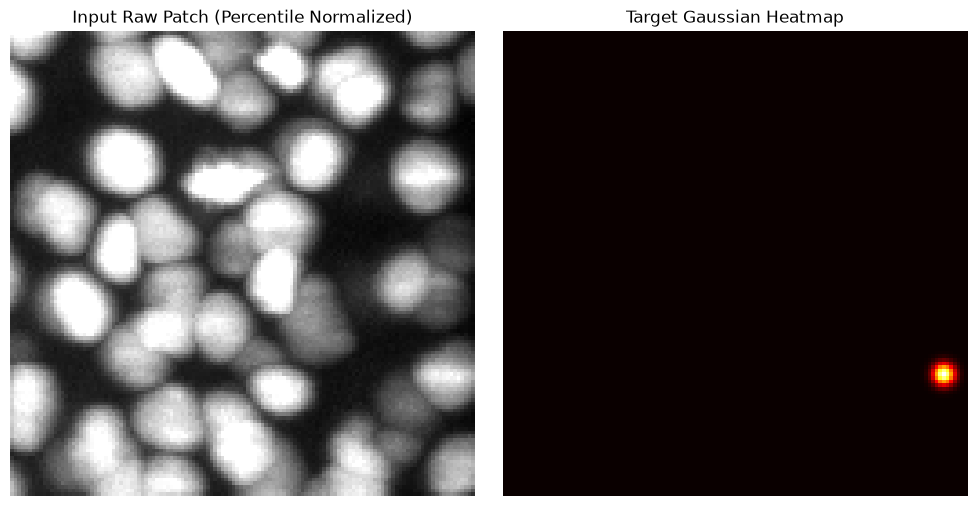

In [40]:
# 1. Inisialisasi ulang dataset dengan kelas yang baru
dataset = CellPatchDataset(zarr_paths, geff_paths)

print(f"✓ Total patch berhasil dipetakan: {len(dataset)}")

# 2. Ambil sampel patch ke-7 (yang ada selnya)
inp_tensor, tgt_tensor = dataset[7]

print("\n--- Hasil Uji Single Item Baru ---")
print(f"Input Shape          : {inp_tensor.shape}")
print(f"Target Shape         : {tgt_tensor.shape}")
print(
    f"Input Range (Min-Max): {inp_tensor.min():.2f} s/d {inp_tensor.max():.2f}"
)
print(f"Target Max (Gaussian): {tgt_tensor.max():.2f}")
print(f"Is Contiguous Memory : {inp_tensor.is_contiguous()}")

# 3. Visualisasi sederhana
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(inp_tensor.squeeze().numpy().max(axis=0), cmap="gray")
axes[0].set_title("Input Raw Patch (Percentile Normalized)")
axes[0].axis("off")

axes[1].imshow(tgt_tensor.squeeze().numpy().max(axis=0), cmap="hot")
axes[1].set_title("Target Gaussian Heatmap")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Cek edge cases kelas

In [ ]:
import random
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm


def run_dataset_health_check(dataset, sample_size=500, num_workers=2):
    print("=== STARTING DATASET HEALTH CHECK ===")

    # -------------------------------------------------------------
    # UJI 1 & 2: Integritas Data (NaN/Inf) & Rasio Patch Berisi Sel
    # -------------------------------------------------------------
    print(
        f"\n[1/2] Checking {sample_size} random patch for data integrity"
        " & ratio..."
    )
    sample_indices = random.sample(
        range(len(dataset)), min(sample_size, len(dataset))
    )

    non_empty_count = 0
    nan_inf_found = False

    for idx in tqdm(sample_indices, desc="Checking patches"):
        inp, tgt = dataset[idx]

        # Cek NaN atau Inf
        if (
            torch.isnan(inp).any()
            or torch.isinf(inp).any()
            or torch.isnan(tgt).any()
            or torch.isinf(tgt).any()
        ):
            print(f"Error: NaN/Inf found on patch index {idx}!")
            nan_inf_found = True
            break

        # Hitung patch yang mengandung sel (target max > 0)
        if tgt.max() > 0:
            non_empty_count += 1

    if not nan_inf_found:
        print("Free from  NaN and Inf!")

    ratio = (non_empty_count / len(sample_indices)) * 100
    print(
        f"Patch Rasio Contains cell: {ratio:.2f}% ({non_empty_count} from"
        f" {len(sample_indices)} patch)"
    )

    if ratio < 5.0:
        print(
            "  Catatan: Rasio sel cukup rendah (<5%). Disarankan"
            " menggunakan Positivity-based Sampling saat training."
        )

    # -------------------------------------------------------------
    # UJI 3: Multiprocessing DataLoader (Kaggle RAM & Process Check)
    # -------------------------------------------------------------
    print(
        f"\n[2/2] Testing DataLoader Multiprocessing (num_workers={num_workers})..."
    )
    try:
        test_loader = DataLoader(
            dataset, batch_size=4, shuffle=True, num_workers=num_workers
        )
        for batch_idx, (b_inp, b_tgt) in enumerate(test_loader):
            if batch_idx == 5:
                break
        print(
            f"Multiprocessing (num_workers={num_workers}) ran smoothly"
            " without memory lock!"
        )
    except Exception as e:
        print(f"Error Multiprocessing: {e}")
        print(
            "   Saran: Di Kaggle, atur num_workers=2 atau num_workers=0 jika"
            " ada isu serialisasi."
        )

    print("\n======================================")
    print("HEALTH CHECK DONE - DATASET READY!")
    print("======================================")

In [42]:
run_dataset_health_check(dataset, sample_size=500, num_workers=2)

=== STARTING DATASET HEALTH CHECK ===

[1/2] Checking 500 random patch for data integrity & ratio...


Checking patches:   0%|          | 0/500 [00:00<?, ?it/s]

Free from  NaN and Inf!
Patch Rasio Contains cell: 45.40% (227 from 500 patch)

[2/2] Testing DataLoader Multiprocessing (num_workers=2)...
Multiprocessing (num_workers=2) ran smoothlywithout memory lock!

HEALTH CHECK DONE - DATASET READY!
